In [1]:
!pip install pandas

In [1]:
!pip install numpy

In [2]:
import numpy as np

In [2]:
import numpy as np
np.__version__

'1.26.4'

In [2]:
!pip install matplotlib


In [3]:
import matplotlib as mat

In [4]:
mat.__version__

'3.10.6'

## M1: Data Preprocessing

In [5]:
# Import libraries
import pandas as pd
import numpy as np

In [6]:
# Load dataset
df = pd.read_csv("kc_house_data.csv")

In [7]:
# Display basic info
df.tail()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [9]:
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [10]:
# Check missing values
print(df.isnull().sum())


id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [11]:
# Drop unnecessary columns
df = df.drop(['id', 'date'], axis=1)

In [12]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [13]:
# Check duplicates
print("Duplicates:", df.duplicated().sum())

Duplicates: 5


In [14]:
# Remove duplicates
df = df.drop_duplicates()

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21608 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21608 non-null  float64
 1   bedrooms       21608 non-null  int64  
 2   bathrooms      21608 non-null  float64
 3   sqft_living    21608 non-null  int64  
 4   sqft_lot       21608 non-null  int64  
 5   floors         21608 non-null  float64
 6   waterfront     21608 non-null  int64  
 7   view           21608 non-null  int64  
 8   condition      21608 non-null  int64  
 9   grade          21608 non-null  int64  
 10  sqft_above     21608 non-null  int64  
 11  sqft_basement  21608 non-null  int64  
 12  yr_built       21608 non-null  int64  
 13  yr_renovated   21608 non-null  int64  
 14  zipcode        21608 non-null  int64  
 15  lat            21608 non-null  float64
 16  long           21608 non-null  float64
 17  sqft_living15  21608 non-null  int64  
 18  sqft_lot15 

## M2: Descriptive Statistics

In [16]:
# Summary statistics
print(df.describe())

              price      bedrooms     bathrooms   sqft_living      sqft_lot  \
count  2.160800e+04  21608.000000  21608.000000  21608.000000  2.160800e+04   
mean   5.400984e+05      3.370927      2.114738   2079.958950  1.510962e+04   
std    3.671646e+05      0.930103      0.770238    918.505805  4.142491e+04   
min    7.500000e+04      0.000000      0.000000    290.000000  5.200000e+02   
25%    3.218375e+05      3.000000      1.750000   1429.250000  5.040000e+03   
50%    4.500000e+05      3.000000      2.250000   1910.000000  7.620000e+03   
75%    6.450000e+05      4.000000      2.500000   2550.000000  1.069050e+04   
max    7.700000e+06     33.000000      8.000000  13540.000000  1.651359e+06   

             floors    waterfront          view     condition         grade  \
count  21608.000000  21608.000000  21608.000000  21608.000000  21608.000000   
mean       1.494146      0.007544      0.234219      3.409478      7.656655   
std        0.539910      0.086527      0.766169    

In [17]:
# Mean house price
print("Mean Price:", df['price'].mean())

Mean Price: 540098.3690299889


In [18]:
# Mean house price
print("Mean Price:", round(df['price'].mean(),2))

Mean Price: 540098.37


In [19]:
# Median
print("Median Price:", df['price'].median())

Median Price: 450000.0


In [20]:
# Correlation
corr = df.corr()
#print(corr['price'].sort_values(ascending=False))

In [21]:
corr

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
price,1.000000,0.308326,0.525146,0.702035,0.089652,0.256893,0.266371,0.397409,0.036345,0.667541,0.605559,0.323839,0.054062,0.126489,-0.053179,0.307002,0.021587,0.585378,0.082435
bedrooms,0.308326,1.000000,0.515956,0.576640,0.031671,0.175608,-0.006591,0.079411,0.028370,0.357143,0.477569,0.303093,0.154410,0.018678,-0.152683,-0.008970,0.129395,0.391571,0.029197
bathrooms,0.525146,0.515956,1.000000,0.754717,0.087751,0.500754,0.063747,0.187892,-0.124941,0.665029,0.685376,0.283824,0.506038,0.050880,-0.203837,0.024587,0.223065,0.568692,0.087192
sqft_living,0.702035,0.576640,0.754717,1.000000,0.172809,0.354181,0.103817,0.284627,-0.058825,0.762893,0.876593,0.435061,0.318253,0.055299,-0.199396,0.052514,0.240150,0.756398,0.183258
sqft_lot,0.089652,0.031671,0.087751,0.172809,1.000000,-0.005113,0.021598,0.074744,-0.008988,0.113688,0.183508,0.015263,0.053154,0.007671,-0.129595,-0.085683,0.229530,0.144596,0.718552
floors,0.256893,0.175608,0.500754,0.354181,-0.005113,1.000000,0.023731,0.029383,-0.263728,0.458074,0.524117,-0.245646,0.489244,0.006193,-0.059153,0.049595,0.125592,0.280080,-0.011180
waterfront,0.266371,-0.006591,0.063747,0.103817,0.021598,0.023731,1.000000,0.401992,0.016648,0.082799,0.072076,0.080584,-0.026150,0.092949,0.030283,-0.014272,-0.041916,0.086466,0.030698
view,0.397409,0.079411,0.187892,0.284627,0.074744,0.029383,0.401992,1.000000,0.045819,0.251426,0.167642,0.276993,-0.053196,0.103203,0.084857,0.006047,-0.078598,0.280391,0.072566
condition,0.036345,0.028370,-0.124941,-0.058825,-0.008988,-0.263728,0.016648,0.045819,1.000000,-0.144599,-0.158273,0.174061,-0.361306,-0.060875,0.002998,-0.014975,-0.106590,-0.092920,-0.003449
grade,0.667541,0.357143,0.665029,0.762893,0.113688,0.458074,0.082799,0.251426,-0.144599,1.000000,0.756090,0.168483,0.446887,0.014396,-0.184875,0.114100,0.198496,0.713396,0.119319


In [22]:
print(corr['price'].sort_values(ascending=False))

price            1.000000
sqft_living      0.702035
grade            0.667541
sqft_above       0.605559
sqft_living15    0.585378
bathrooms        0.525146
view             0.397409
sqft_basement    0.323839
bedrooms         0.308326
lat              0.307002
waterfront       0.266371
floors           0.256893
yr_renovated     0.126489
sqft_lot         0.089652
sqft_lot15       0.082435
yr_built         0.054062
condition        0.036345
long             0.021587
zipcode         -0.053179
Name: price, dtype: float64


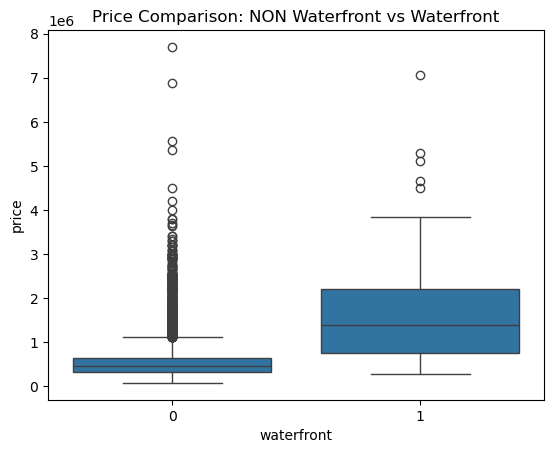

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='waterfront', y='price', data=df)
plt.title("Price Comparison: NON Waterfront vs Waterfront")
plt.show()

## M3: Probability Concepts

In [25]:
# Total number of houses
total = len(df)

# Houses with price > 500000
expensive = len(df[df['price'] > 500000])

# Probability
prob = expensive / total

print("Probability of expensive house:", prob)

Probability of expensive house: 0.41878008145131435


##  M4: Statistical Inference

In [26]:
# Average price based on waterfront
group_mean = df.groupby('waterfront')['price'].mean()

print(group_mean)

waterfront
0    5.315719e+05
1    1.661876e+06
Name: price, dtype: float64


In [27]:
df.groupby('waterfront')['price'].mean().apply(lambda x: format(x, '.2f'))

waterfront
0     531571.92
1    1661876.02
Name: price, dtype: object

In [28]:
group_mean[0]

np.float64(531571.9172767545)

In [29]:
group_mean[0] ,group_mean[1]

(np.float64(531571.9172767545), np.float64(1661876.0245398772))

In [30]:
if group_mean[1] > group_mean[0]:
    print("Waterfront houses are more expensive")
else:
    print("No clear difference")

Waterfront houses are more expensive


## M5: Regression

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error

# Features and target
X = df.drop('price', axis=1)
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 128203.50296474094
RMSE: 205759.77231423606
R2 Score: 0.7026188047056415


In [34]:
import matplotlib.pyplot as plt

## M6: Reporting & Visualization

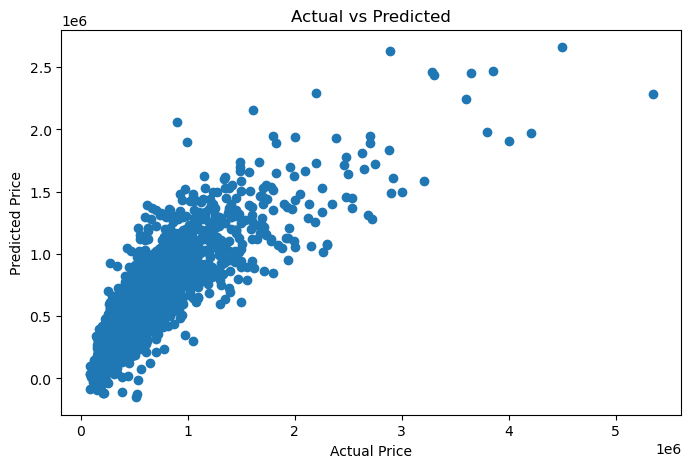

In [35]:
# Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

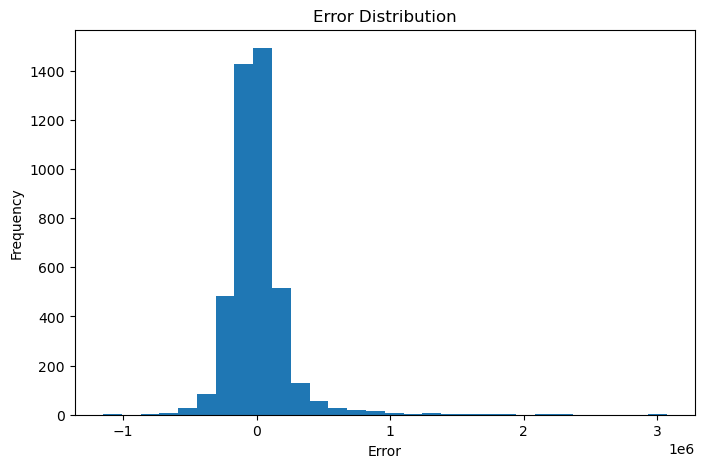

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(y_test - y_pred, bins=30)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

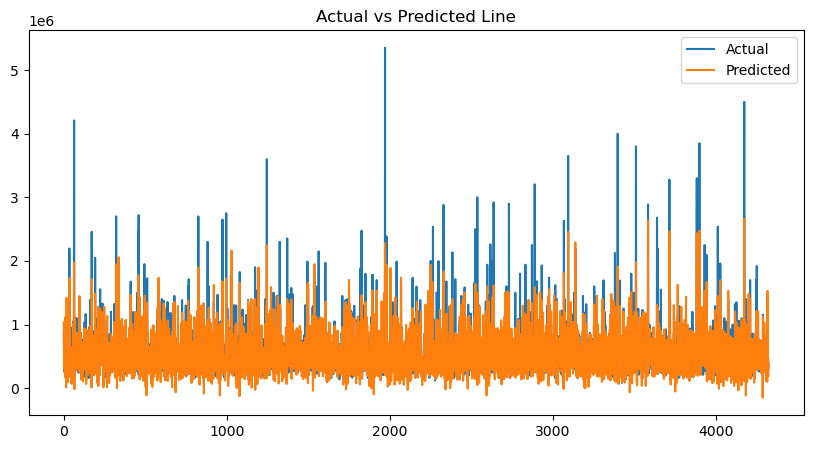

In [37]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Line")
plt.show()

In [49]:
X = df.drop('price',axis=1)
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X, y)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 128107.76548697743
RMSE: 205444.47882099045
R2 Score: 0.7035294833774863


In [54]:
X = df[['sqft_living', 'grade', 'sqft_above']]
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X, y)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

#import warnings
#warnings.filterwarnings('ignore')

print("Predictions:", model.predict([[2000,3,4]]))

MAE: 164301.42313012638
RMSE: 253992.13784206187
R2 Score: 0.546859261147758
Predictions: [147584.57119354]


In [55]:
import pandas as pd

new_data = pd.DataFrame([[2000, 3, 2]],
                        columns=['sqft_living', 'grade', 'sqft_above'])

prediction = model.predict(new_data)

print("Predicted Price:", prediction[0])

Predicted Price: 147740.08608646656


In [56]:
X = df[['sqft_living', 'grade', 'sqft_above','sqft_living15','bathrooms','view','sqft_basement','bedrooms','lat','waterfront','floors']]
y = df['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X, y)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

#print("Predictions:", model.predict(X.head()))
#print("Predictions:", model.predict([[2000,3,4]]))

MAE: 137243.46851917094
RMSE: 218633.37933539567
R2 Score: 0.6642426747362898
